# Spheroid inference

In [ ]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
import os
import sys
cwd = os.getcwd()
S2F_ROOT = os.path.normpath(os.path.join(cwd, ".."))
sys.path.insert(0, S2F_ROOT)

import torch
from data.cell_dataset import load_brightfield_loader
from models.s2f_model import create_s2f_model
from utils.inference import plot_inference_samples_spheroid, save_all_predictions_spheroid

## 1. Config

In [ ]:
CHECKPOINT_PATH = os.path.join(S2F_ROOT, 'ckp', 'spheroid', 'ckp_spheroid_FN.pth')
INFERENCE_FOLDER =  os.path.normpath(os.path.join(S2F_ROOT, 'dataset', 'spheroid_samples')) # folder with brightfield images
IMAGE_SIZE = 1024
BATCH_SIZE = 2
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

## 2. Load model (S2FSpheroidGenerator)

In [7]:
generator, _ = create_s2f_model(in_channels=1, model_type='s2f_spheroid')
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
state_dict = checkpoint.get('generator_state_dict') or checkpoint.get('model_state_dict') or checkpoint
generator.load_state_dict(state_dict, strict=True)
generator.set_output_mode(use_tanh=False)
generator = generator.to(DEVICE)
_ = generator.eval()
print('Model loaded from', CHECKPOINT_PATH)

Generator set to sigmoid output mode [0, 1] for inference/evaluation
Model loaded from c:\Users\Kaveh\Documents\Shape2Force\ckp\spheroid\ckp_spheroid_FN.pth


## 3. Load data (brightfield only)

In [8]:
loader = load_brightfield_loader(INFERENCE_FOLDER, img_size=IMAGE_SIZE, batch_size=BATCH_SIZE)
print(f"Samples: {len(loader.dataset)}")

Samples: 5


## 4. Plot sample predictions

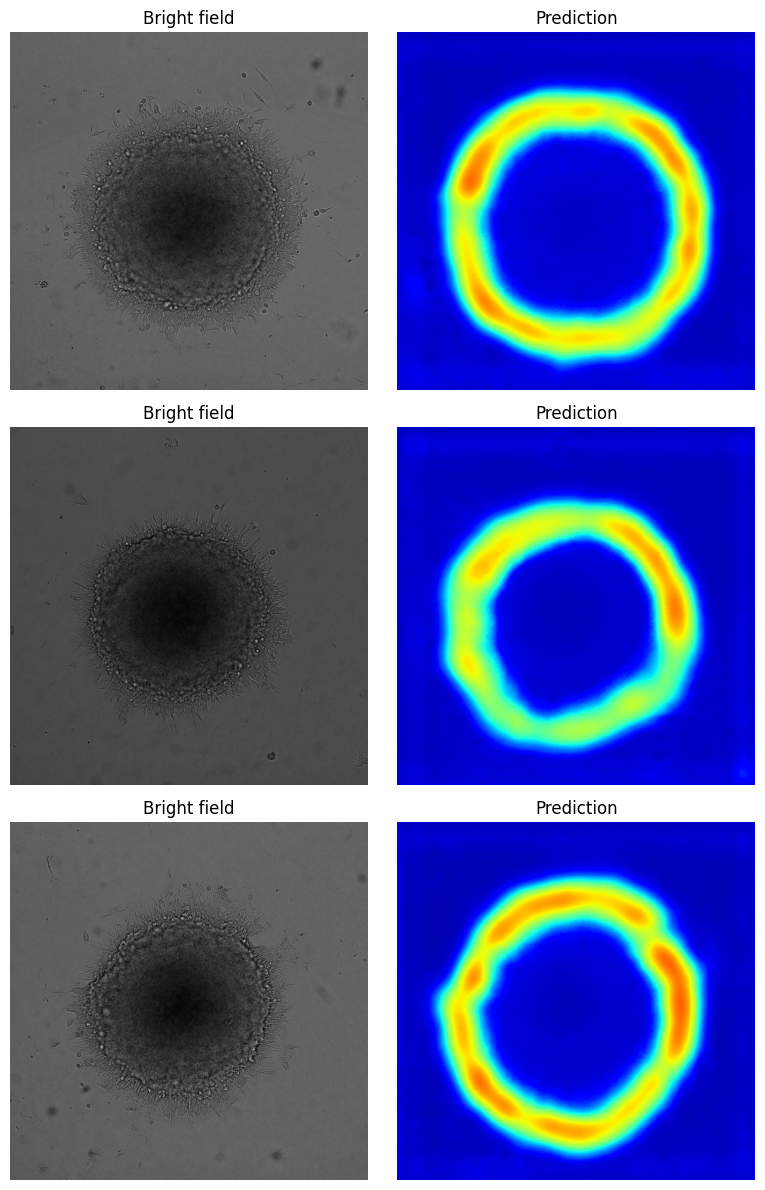

In [9]:
plot_inference_samples_spheroid(loader, generator, n_samples=3, device=DEVICE)

## 5. Save all predictions (optional)

In [ ]:
SAVE_PREDICTION_PATH = ""  # e.g. os.path.join(S2F_ROOT, 'predictions_spheroid')
if SAVE_PREDICTION_PATH:
    save_all_predictions_spheroid(loader, generator, SAVE_PREDICTION_PATH, device=DEVICE)